In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
customer_path = "../Data/raw/Bank Customer Segmentation.csv"

df_customer = pd.read_csv(customer_path)

print("Bank Customer Segmentation Dataset")
print("=" * 50)
print(f"Rows    : {df_customer.shape[0]:,}")
print(f"Columns : {df_customer.shape[1]}")

Bank Customer Segmentation Dataset
Rows    : 1,048,567
Columns : 9


In [3]:
credit_path = "../Data/raw/default of credit card clients.xls"

df_credit = pd.read_excel(
    credit_path,
    header=1
)

print("Credit Card Default Dataset")
print("=" * 50)
print(f"Rows    : {df_credit.shape[0]:,}")
print(f"Columns : {df_credit.shape[1]}")

Credit Card Default Dataset
Rows    : 30,000
Columns : 25


In [4]:
df_credit.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [5]:
marketing_path = "../Data/raw/Bank Marketing/bank/bank-full.csv"

df_marketing = pd.read_csv(
    marketing_path,
    sep=";"
)

print("Bank Marketing Dataset")
print("=" * 50)
print(f"Rows    : {df_marketing.shape[0]:,}")
print(f"Columns : {df_marketing.shape[1]}")

Bank Marketing Dataset
Rows    : 45,211
Columns : 17


In [6]:
df_marketing.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [7]:
datasets = {
    "Customer Transactions": df_customer,
    "Credit Default": df_credit,
    "Bank Marketing": df_marketing
}

for name, df in datasets.items():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    print(f"Rows: {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]}")
    print("\nData Types:")
    print(df.dtypes)
    print("\nMissing Values:")
    print(df.isnull().sum())
    print(f"\nDuplicate Rows: {df.duplicated().sum():,}")


Customer Transactions
Rows: 1,048,567
Columns: 9

Data Types:
TransactionID                  str
CustomerID                     str
CustomerDOB                    str
CustGender                     str
CustLocation                   str
CustAccountBalance         float64
TransactionDate                str
TransactionTime              int64
TransactionAmount (INR)    float64
dtype: object

Missing Values:
TransactionID                 0
CustomerID                    0
CustomerDOB                3397
CustGender                 1100
CustLocation                151
CustAccountBalance         2369
TransactionDate               0
TransactionTime               0
TransactionAmount (INR)       0
dtype: int64

Duplicate Rows: 0

Credit Default
Rows: 30,000
Columns: 25

Data Types:
ID                            int64
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
P

In [8]:
# Detailed overview of all datasets

for name, df in datasets.items():
    print("\n" + "=" * 80)
    print(f"DATASET: {name}")
    print("=" * 80)

    print(f"\nShape: {df.shape[0]:,} rows × {df.shape[1]} columns")

    print("\nFirst 5 rows:")
    display(df.head())

    print("\nColumn Names:")
    print(df.columns.tolist())

    print("\nData Types:")
    display(df.dtypes.to_frame("Data Type"))

    print("\nMissing Values:")
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)

    missing_summary = pd.DataFrame({
        "Missing Values": missing,
        "Missing Percentage": missing_pct
    })

    display(missing_summary[missing_summary["Missing Values"] > 0])

    print("\nDuplicate Rows:")
    print(f"{df.duplicated().sum():,}")


DATASET: Customer Transactions

Shape: 1,048,567 rows × 9 columns

First 5 rows:


,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5



Column Names:
['TransactionID', 'CustomerID', 'CustomerDOB', 'CustGender', 'CustLocation', 'CustAccountBalance', 'TransactionDate', 'TransactionTime', 'TransactionAmount (INR)']

Data Types:


,Data Type
TransactionID,str
CustomerID,str
CustomerDOB,str
CustGender,str
CustLocation,str
CustAccountBalance,float64
TransactionDate,str
TransactionTime,int64
TransactionAmount (INR),float64



Missing Values:


...


Column Names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Data Types:


,Data Type
age,int64
job,str
marital,str
education,str
default,str
balance,int64
housing,str
loan,str
contact,str
day,int64



Missing Values:


,Missing Values,Missing Percentage



Duplicate Rows:
0


In [9]:
# Numerical feature analysis

for name, df in datasets.items():
    print("\n" + "=" * 80)
    print(f"NUMERICAL ANALYSIS: {name}")
    print("=" * 80)

    numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

    print(f"\nNumber of numerical columns: {len(numerical_columns)}")
    print("\nNumerical columns:")
    print(numerical_columns)

    if numerical_columns:
        display(df[numerical_columns].describe().T)


NUMERICAL ANALYSIS: Customer Transactions

Number of numerical columns: 3

Numerical columns:
['CustAccountBalance', 'TransactionTime', 'TransactionAmount (INR)']


,count,mean,std,min,25%,50%,75%,max
CustAccountBalance,1046198.0,115403.540056,846485.380601,0.0,4721.76,16792.18,57657.36,1.150355e+08
TransactionTime,1048567.0,157087.529393,51261.854022,0.0,124030.00,164226.00,200010.00,2.359590e+05
TransactionAmount (INR),1048567.0,1574.335003,6574.742978,0.0,161.00,459.03,1200.00,1.560035e+06



NUMERICAL ANALYSIS: Credit Default

Number of numerical columns: 25

Numerical columns:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0



NUMERICAL ANALYSIS: Bank Marketing

Number of numerical columns: 7

Numerical columns:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


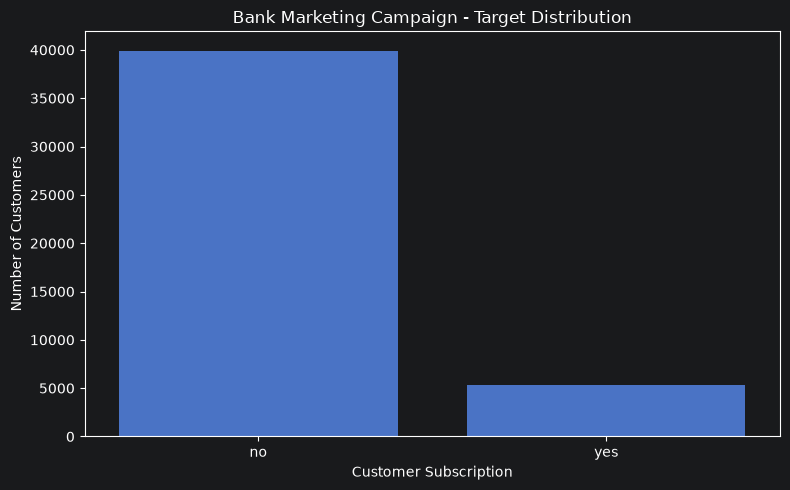

In [10]:
# Bank Marketing: Target distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_marketing,
    x="y"
)

plt.title("Bank Marketing Campaign - Target Distribution")
plt.xlabel("Customer Subscription")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [11]:
# Create copies for data cleaning

customer_clean = df_customer.copy()
credit_clean = df_credit.copy()
marketing_clean = df_marketing.copy()

print("Clean copies created successfully.")

Clean copies created successfully.


In [12]:
def clean_column_names(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("-", "_")
        .str.replace("/", "_")
    )
    return df


customer_clean = clean_column_names(customer_clean)
credit_clean = clean_column_names(credit_clean)
marketing_clean = clean_column_names(marketing_clean)

print("Column names standardized.")

Column names standardized.


In [13]:
print("Customer Dataset:")
print(customer_clean.columns.tolist())

print("\nCredit Dataset:")
print(credit_clean.columns.tolist())

print("\nMarketing Dataset:")
print(marketing_clean.columns.tolist())

Customer Dataset:
['transactionid', 'customerid', 'customerdob', 'custgender', 'custlocation', 'custaccountbalance', 'transactiondate', 'transactiontime', 'transactionamount_(inr)']

Credit Dataset:
['id', 'limit_bal', 'sex', 'education', 'marriage', 'age', 'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6', 'bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6', 'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6', 'default_payment_next_month']

Marketing Dataset:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [14]:
# Check unique values in important categorical columns

marketing_columns = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome",
    "y"
]

for column in marketing_columns:
    print(f"\n{column.upper()}")
    print(marketing_clean[column].value_counts(dropna=False))


JOB
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

MARITAL
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

EDUCATION
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

DEFAULT
default
no     44396
yes      815
Name: count, dtype: int64

HOUSING
housing
yes    25130
no     20081
Name: count, dtype: int64

LOAN
loan
no     37967
yes     7244
Name: count, dtype: int64

CONTACT
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

MONTH
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count

In [15]:
# Identify potential outliers using the IQR method

def outlier_summary(df):
    numerical_columns = df.select_dtypes(include=np.number).columns

    results = []

    for column in numerical_columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = ((df[column] < lower_bound) |
                    (df[column] > upper_bound)).sum()

        results.append({
            "column": column,
            "Q1": Q1,
            "Q3": Q3,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outliers": outliers,
            "outlier_percentage": round(
                outliers / len(df) * 100, 2
            )
        })

    return pd.DataFrame(results)


marketing_outliers = outlier_summary(marketing_clean)

display(marketing_outliers)

,column,Q1,Q3,lower_bound,upper_bound,outliers,outlier_percentage
0,age,33.0,48.0,10.5,70.5,487,1.08
1,balance,72.0,1428.0,-1962.0,3462.0,4729,10.46
2,day,8.0,21.0,-11.5,40.5,0,0.00
3,duration,103.0,319.0,-221.0,643.0,3235,7.16
4,campaign,1.0,3.0,-2.0,6.0,3064,6.78
5,pdays,-1.0,-1.0,-1.0,-1.0,8257,18.26
6,previous,0.0,0.0,0.0,0.0,8257,18.26


In [16]:
# Save initial cleaned datasets

customer_clean.to_csv(
    "../Data/processed/customer_clean.csv",
    index=False
)

credit_clean.to_csv(
    "../Data/processed/credit_default_clean.csv",
    index=False
)

marketing_clean.to_csv(
    "../Data/processed/bank_marketing_clean.csv",
    index=False
)

print("Processed datasets saved successfully.")

Processed datasets saved successfully.


In [17]:
# Customer dataset - detailed inspection

print("CUSTOMER SEGMENTATION DATASET")
print("=" * 80)

print(f"Rows    : {customer_clean.shape[0]:,}")
print(f"Columns : {customer_clean.shape[1]}")

print("\nColumn Names:")
print(customer_clean.columns.tolist())

print("\nData Types:")
display(customer_clean.dtypes.to_frame("Data Type"))

print("\nFirst 5 Rows:")
display(customer_clean.head())

CUSTOMER SEGMENTATION DATASET
Rows    : 1,048,567
Columns : 9

Column Names:
['transactionid', 'customerid', 'customerdob', 'custgender', 'custlocation', 'custaccountbalance', 'transactiondate', 'transactiontime', 'transactionamount_(inr)']

Data Types:


,Data Type
transactionid,str
customerid,str
customerdob,str
custgender,str
custlocation,str
custaccountbalance,float64
transactiondate,str
transactiontime,int64
transactionamount_(inr),float64



First 5 Rows:


,transactionid,customerid,customerdob,custgender,custlocation,custaccountbalance,transactiondate,transactiontime,transactionamount_(inr)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5


In [18]:
# Numerical summary

customer_numeric = customer_clean.select_dtypes(include=np.number)

print("NUMERICAL SUMMARY")
print("=" * 80)

display(customer_numeric.describe().T)

NUMERICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
custaccountbalance,1046198.0,115403.540056,846485.380601,0.0,4721.76,16792.18,57657.36,1.150355e+08
transactiontime,1048567.0,157087.529393,51261.854022,0.0,124030.00,164226.00,200010.00,2.359590e+05
transactionamount_(inr),1048567.0,1574.335003,6574.742978,0.0,161.00,459.03,1200.00,1.560035e+06


In [19]:
# Missing values and duplicates

print("MISSING VALUES")
print("=" * 80)

customer_missing = pd.DataFrame({
    "missing_values": customer_clean.isnull().sum(),
    "missing_percentage": (
        customer_clean.isnull().sum() /
        len(customer_clean) * 100
    ).round(2)
})

display(customer_missing)

print("\nDuplicate Rows:", customer_clean.duplicated().sum())

MISSING VALUES


,missing_values,missing_percentage
transactionid,0,0.00
customerid,0,0.00
customerdob,3397,0.32
custgender,1100,0.10
custlocation,151,0.01
custaccountbalance,2369,0.23
transactiondate,0,0.00
transactiontime,0,0.00
transactionamount_(inr),0,0.00



Duplicate Rows: 0


In [20]:
# Unique values in categorical columns

customer_categorical = customer_clean.select_dtypes(
    include="object"
).columns

print("CATEGORICAL FEATURES")
print("=" * 80)

for column in customer_categorical:
    print(f"\n{column}")
    print("Unique values:", customer_clean[column].nunique())
    print(customer_clean[column].value_counts().head(10))

CATEGORICAL FEATURES

transactionid
Unique values: 1048567


/var/folders/d_/h5zv9x_s3l5f9wzs6__txvn40000gn/T/ipykernel_19350/1343798613.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  customer_categorical = customer_clean.select_dtypes(


transactionid
T1     1
T2     1
T3     1
T4     1
T5     1
T6     1
T7     1
T8     1
T9     1
T10    1
Name: count, dtype: int64

customerid
Unique values: 884265
customerid
C4327447    6
C3226689    6
C5533885    6
C6624352    6
C4021562    6
C6735477    6
C1736254    6
C7537344    6
C5418253    6
C5531319    6
Name: count, dtype: int64

customerdob
Unique values: 17254
customerdob
1/1/1800    57339
1/1/89        809
1/1/90        784
6/8/91        699
1/1/91        666
1/1/92        633
1/7/90        619
21/11/86      602
1/1/87        601
1/1/88        592
Name: count, dtype: int64

custgender
Unique values: 3
custgender
M    765530
F    281936
T         1
Name: count, dtype: int64

custlocation
Unique values: 9355
custlocation
MUMBAI       103595
NEW DELHI     84928
BANGALORE     81555
GURGAON       73818
DELHI         71019
NOIDA         32784
CHENNAI       30009
PUNE          25851
HYDERABAD     23049
THANE         21505
Name: count, dtype: int64

transactiondate
Unique values: 

In [21]:
# Categorical feature inspection
# Explicitly include object and string columns for pandas compatibility

customer_categorical = customer_clean.select_dtypes(
    include=["object", "str"]
).columns

print("CATEGORICAL FEATURES")
print("=" * 80)

for column in customer_categorical:
    print(f"\n{column}")
    print("Unique values:", customer_clean[column].nunique())
    print(customer_clean[column].value_counts().head(10))

CATEGORICAL FEATURES

transactionid
Unique values: 1048567
transactionid
T1     1
T2     1
T3     1
T4     1
T5     1
T6     1
T7     1
T8     1
T9     1
T10    1
Name: count, dtype: int64

customerid
Unique values: 884265
customerid
C4327447    6
C3226689    6
C5533885    6
C6624352    6
C4021562    6
C6735477    6
C1736254    6
C7537344    6
C5418253    6
C5531319    6
Name: count, dtype: int64

customerdob
Unique values: 17254
customerdob
1/1/1800    57339
1/1/89        809
1/1/90        784
6/8/91        699
1/1/91        666
1/1/92        633
1/7/90        619
21/11/86      602
1/1/87        601
1/1/88        592
Name: count, dtype: int64

custgender
Unique values: 3
custgender
M    765530
F    281936
T         1
Name: count, dtype: int64

custlocation
Unique values: 9355
custlocation
MUMBAI       103595
NEW DELHI     84928
BANGALORE     81555
GURGAON       73818
DELHI         71019
NOIDA         32784
CHENNAI       30009
PUNE          25851
HYDERABAD     23049
THANE         21505

In [22]:
print("ALL CUSTOMER DATASET COLUMNS")
print("=" * 80)

for i, column in enumerate(customer_clean.columns, start=1):
    print(f"{i:2}. {column}")

ALL CUSTOMER DATASET COLUMNS
 1. transactionid
 2. customerid
 3. customerdob
 4. custgender
 5. custlocation
 6. custaccountbalance
 7. transactiondate
 8. transactiontime
 9. transactionamount_(inr)


In [23]:
print("\nNUMERICAL COLUMNS")
print("=" * 80)

customer_numeric = customer_clean.select_dtypes(
    include=np.number
)

print(customer_numeric.columns.tolist())

display(customer_numeric.describe().T)


NUMERICAL COLUMNS
['custaccountbalance', 'transactiontime', 'transactionamount_(inr)']


,count,mean,std,min,25%,50%,75%,max
custaccountbalance,1046198.0,115403.540056,846485.380601,0.0,4721.76,16792.18,57657.36,1.150355e+08
transactiontime,1048567.0,157087.529393,51261.854022,0.0,124030.00,164226.00,200010.00,2.359590e+05
transactionamount_(inr),1048567.0,1574.335003,6574.742978,0.0,161.00,459.03,1200.00,1.560035e+06


In [24]:
# Investigate suspicious customer DOB values

print("DOB QUALITY CHECK")
print("=" * 80)

print("Invalid placeholder DOB count:")
print(
    (customer_clean["customerdob"] == "1/1/1800").sum()
)

print("\nEarliest DOB values:")
print(
    customer_clean["customerdob"]
    .value_counts()
    .sort_index()
    .head(20)
)

DOB QUALITY CHECK
Invalid placeholder DOB count:
57339

Earliest DOB values:
customerdob
1/1/00          5
1/1/01         10
1/1/02          4
1/1/1800    57339
1/1/30          1
1/1/31          2
1/1/33          1
1/1/34          7
1/1/35          1
1/1/36          6
1/1/39          5
1/1/40          1
1/1/41         16
1/1/42          5
1/1/43         15
1/1/44         36
1/1/45          1
1/1/46          1
1/1/47         17
1/1/48         11
Name: count, dtype: int64


In [25]:
# Create a proper datetime version of customer DOB

customer_clean["customerdob_clean"] = pd.to_datetime(
    customer_clean["customerdob"],
    format="%d/%m/%y",
    errors="coerce"
)

# Replace the invalid 1800 placeholder with missing
customer_clean.loc[
    customer_clean["customerdob"] == "1/1/1800",
    "customerdob_clean"
] = pd.NaT

print("DOB conversion completed.")

print("\nValid DOBs:")
print(customer_clean["customerdob_clean"].notna().sum())

print("\nMissing/invalid DOBs:")
print(customer_clean["customerdob_clean"].isna().sum())

DOB conversion completed.

Valid DOBs:
987831

Missing/invalid DOBs:
60736


In [26]:
# Investigate the unusual gender value

unusual_gender = customer_clean[
    customer_clean["custgender"] == "T"
]

display(unusual_gender)

,transactionid,customerid,customerdob,custgender,custlocation,custaccountbalance,transactiondate,transactiontime,transactionamount_(inr),customerdob_clean
959987,T959988,C3380368,1/1/1800,T,CHENNAI,50050.0,10/9/16,170731,32500.0,NaT


In [27]:
print("ALL CUSTOMER DATASET COLUMNS")
print("=" * 80)

for i, column in enumerate(customer_clean.columns, start=1):
    print(f"{i:2}. {column}")

ALL CUSTOMER DATASET COLUMNS
 1. transactionid
 2. customerid
 3. customerdob
 4. custgender
 5. custlocation
 6. custaccountbalance
 7. transactiondate
 8. transactiontime
 9. transactionamount_(inr)
10. customerdob_clean


In [28]:
# Convert transaction date to datetime

customer_clean["transactiondate_clean"] = pd.to_datetime(
    customer_clean["transactiondate"],
    format="%d/%m/%y",
    errors="coerce"
)

print("Transaction date conversion completed.")

print("\nInvalid transaction dates:")
print(customer_clean["transactiondate_clean"].isna().sum())

print("\nDate range:")
print(
    customer_clean["transactiondate_clean"].min(),
    "to",
    customer_clean["transactiondate_clean"].max()
)

Transaction date conversion completed.

Invalid transaction dates:
0

Date range:
2016-08-01 00:00:00 to 2016-10-21 00:00:00


In [29]:
amount_column = "transactionamount_(inr)"

print("Transaction Amount Analysis")
print("=" * 60)

print("Missing values:", customer_clean[amount_column].isna().sum())
print("Zero values:", (customer_clean[amount_column] == 0).sum())
print("Negative values:", (customer_clean[amount_column] < 0).sum())

display(customer_clean[amount_column].describe())

Transaction Amount Analysis
Missing values: 0
Zero values: 835
Negative values: 0


count    1.048567e+06
mean     1.574335e+03
std      6.574743e+03
min      0.000000e+00
25%      1.610000e+02
50%      4.590300e+02
75%      1.200000e+03
max      1.560035e+06
Name: transactionamount_(inr), dtype: float64

In [30]:
balance_column = "custaccountbalance"

print("Account Balance Analysis")
print("=" * 60)

print("Missing values:", customer_clean[balance_column].isna().sum())
print("Negative balances:", (customer_clean[balance_column] < 0).sum())

display(customer_clean[balance_column].describe())

Account Balance Analysis
Missing values: 2369
Negative balances: 0


count    1.046198e+06
mean     1.154035e+05
std      8.464854e+05
min      0.000000e+00
25%      4.721760e+03
50%      1.679218e+04
75%      5.765736e+04
max      1.150355e+08
Name: custaccountbalance, dtype: float64

In [31]:
amount_column = "transactionamount_(inr)"

print("Transaction Amount Analysis")
print("=" * 60)

print("Missing values:", customer_clean[amount_column].isna().sum())
print("Zero values:", (customer_clean[amount_column] == 0).sum())
print("Negative values:", (customer_clean[amount_column] < 0).sum())

display(customer_clean[amount_column].describe())

Transaction Amount Analysis
Missing values: 0
Zero values: 835
Negative values: 0


count    1.048567e+06
mean     1.574335e+03
std      6.574743e+03
min      0.000000e+00
25%      1.610000e+02
50%      4.590300e+02
75%      1.200000e+03
max      1.560035e+06
Name: transactionamount_(inr), dtype: float64

In [32]:
customer_master = (
    customer_clean
    .groupby("customerid")
    .agg(
        total_transactions=("transactionid", "count"),
        total_spending_inr=(amount_column, "sum"),
        average_transaction_inr=(amount_column, "mean"),
        maximum_transaction_inr=(amount_column, "max"),
        minimum_transaction_inr=(amount_column, "min"),
        average_account_balance_inr=(balance_column, "mean"),
        maximum_account_balance_inr=(balance_column, "max"),
        last_transaction_date=("transactiondate_clean", "max"),
        first_transaction_date=("transactiondate_clean", "min")
    )
    .reset_index()
)

print("Customer Master Table created successfully.")
print(f"Customers: {len(customer_master):,}")
print(f"Features : {customer_master.shape[1]}")

display(customer_master.head())

Customer Master Table created successfully.
Customers: 884,265
Features : 10


,customerid,total_transactions,total_spending_inr,average_transaction_inr,maximum_transaction_inr,minimum_transaction_inr,average_account_balance_inr,maximum_account_balance_inr,last_transaction_date,first_transaction_date
0,C1010011,2,5106.0,2553.0,4750.0,356.0,76340.635,120180.54,2016-09-26,2016-08-09
1,C1010012,1,1499.0,1499.0,1499.0,1499.0,24204.490,24204.49,2016-08-14,2016-08-14
2,C1010014,2,1455.0,727.5,1205.0,250.0,100112.950,161848.76,2016-08-07,2016-08-01
3,C1010018,1,30.0,30.0,30.0,30.0,496.180,496.18,2016-09-15,2016-09-15
4,C1010024,1,5000.0,5000.0,5000.0,5000.0,87058.650,87058.65,2016-08-18,2016-08-18


In [33]:
customer_profile = (
    customer_clean
    .sort_values("transactiondate_clean")
    .groupby("customerid")
    .agg(
        gender=("custgender", "last"),
        location=("custlocation", "last"),
        date_of_birth=("customerdob_clean", "last")
    )
    .reset_index()
)

customer_master = customer_master.merge(
    customer_profile,
    on="customerid",
    how="left"
)

print("Customer Master Table updated.")
print(f"Shape: {customer_master.shape}")

display(customer_master.head())

Customer Master Table updated.
Shape: (884265, 13)


,customerid,total_transactions,total_spending_inr,average_transaction_inr,maximum_transaction_inr,minimum_transaction_inr,average_account_balance_inr,maximum_account_balance_inr,last_transaction_date,first_transaction_date,gender,location,date_of_birth
0,C1010011,2,5106.0,2553.0,4750.0,356.0,76340.635,120180.54,2016-09-26,2016-08-09,F,NOIDA,1992-08-19
1,C1010012,1,1499.0,1499.0,1499.0,1499.0,24204.490,24204.49,2016-08-14,2016-08-14,M,MUMBAI,1994-07-28
2,C1010014,2,1455.0,727.5,1205.0,250.0,100112.950,161848.76,2016-08-07,2016-08-01,M,MUMBAI,1984-08-19
3,C1010018,1,30.0,30.0,30.0,30.0,496.180,496.18,2016-09-15,2016-09-15,F,CHAMPARAN,1990-05-29
4,C1010024,1,5000.0,5000.0,5000.0,5000.0,87058.650,87058.65,2016-08-18,2016-08-18,M,KOLKATA,2065-06-21


In [34]:
# Calculate customer age

reference_date = customer_master["last_transaction_date"].max()

customer_master["age"] = (
    (reference_date - customer_master["date_of_birth"]).dt.days / 365.25
).round(1)

print("Reference date:", reference_date)

print("\nAge statistics:")
display(customer_master["age"].describe())

print("\nMissing ages:",
      customer_master["age"].isna().sum())

print("Age below 18:",
      (customer_master["age"] < 18).sum())

print("Age above 100:",
      (customer_master["age"] > 100).sum())

Reference date: 2016-10-21 00:00:00

Age statistics:


count    840889.000000
mean         25.823879
std          17.815232
min         -52.200000
25%          24.700000
50%          28.200000
75%          33.100000
max          47.800000
Name: age, dtype: float64


Missing ages: 43376
Age below 18: 47880
Age above 100: 0


In [35]:
# Create RFM features

customer_master["recency_days"] = (
    reference_date - customer_master["last_transaction_date"]
).dt.days

customer_master["frequency"] = customer_master["total_transactions"]

customer_master["monetary_value_inr"] = (
    customer_master["total_spending_inr"]
)

print("RFM features created successfully.")

display(
    customer_master[
        [
            "customerid",
            "recency_days",
            "frequency",
            "monetary_value_inr"
        ]
    ].head(10)
)

RFM features created successfully.


,customerid,recency_days,frequency,monetary_value_inr
0,C1010011,25,2,5106.0
1,C1010012,68,1,1499.0
2,C1010014,75,2,1455.0
3,C1010018,36,1,30.0
4,C1010024,64,1,5000.0
5,C1010028,53,1,557.0
6,C1010031,78,2,1864.0
7,C1010035,55,2,750.0
8,C1010036,56,1,208.0
9,C1010037,73,1,19680.0


In [36]:
# Calculate customer activity period

customer_master["activity_days"] = (
    customer_master["last_transaction_date"]
    - customer_master["first_transaction_date"]
).dt.days

customer_master["activity_months"] = (
    customer_master["activity_days"] / 30.44
).round(2)

display(
    customer_master[
        [
            "customerid",
            "first_transaction_date",
            "last_transaction_date",
            "activity_days",
            "activity_months"
        ]
    ].head(10)
)

,customerid,first_transaction_date,last_transaction_date,activity_days,activity_months
0,C1010011,2016-08-09,2016-09-26,48,1.58
1,C1010012,2016-08-14,2016-08-14,0,0.00
2,C1010014,2016-08-01,2016-08-07,6,0.20
3,C1010018,2016-09-15,2016-09-15,0,0.00
4,C1010024,2016-08-18,2016-08-18,0,0.00
5,C1010028,2016-08-29,2016-08-29,0,0.00
6,C1010031,2016-08-03,2016-08-04,1,0.03
7,C1010035,2016-08-01,2016-08-27,26,0.85
8,C1010036,2016-08-26,2016-08-26,0,0.00
9,C1010037,2016-08-09,2016-08-09,0,0.00


In [37]:
# Transaction frequency rate

customer_master["transactions_per_month"] = np.where(
    customer_master["activity_months"] > 0,
    customer_master["frequency"] /
    customer_master["activity_months"],
    customer_master["frequency"]
)

customer_master["transactions_per_month"] = (
    customer_master["transactions_per_month"].round(2)
)

display(
    customer_master[
        [
            "customerid",
            "frequency",
            "activity_months",
            "transactions_per_month"
        ]
    ].head(10)
)

,customerid,frequency,activity_months,transactions_per_month
0,C1010011,2,1.58,1.27
1,C1010012,1,0.00,1.00
2,C1010014,2,0.20,10.00
3,C1010018,1,0.00,1.00
4,C1010024,1,0.00,1.00
5,C1010028,1,0.00,1.00
6,C1010031,2,0.03,66.67
7,C1010035,2,0.85,2.35
8,C1010036,1,0.00,1.00
9,C1010037,1,0.00,1.00


In [38]:
print("FINAL CUSTOMER MASTER")
print("=" * 80)

print("Shape:", customer_master.shape)

print("\nColumns:")
for i, column in enumerate(customer_master.columns, 1):
    print(f"{i:2}. {column}")

print("\nMissing values:")
display(
    customer_master.isnull().sum()
)

FINAL CUSTOMER MASTER
Shape: (884265, 20)

Columns:
 1. customerid
 2. total_transactions
 3. total_spending_inr
 4. average_transaction_inr
 5. maximum_transaction_inr
 6. minimum_transaction_inr
 7. average_account_balance_inr
 8. maximum_account_balance_inr
 9. last_transaction_date
10. first_transaction_date
11. gender
12. location
13. date_of_birth
14. age
15. recency_days
16. frequency
17. monetary_value_inr
18. activity_days
19. activity_months
20. transactions_per_month

Missing values:


customerid                         0
total_transactions                 0
total_spending_inr                 0
average_transaction_inr            0
maximum_transaction_inr            0
minimum_transaction_inr            0
average_account_balance_inr     1665
maximum_account_balance_inr     1665
last_transaction_date              0
first_transaction_date             0
gender                           803
location                         114
date_of_birth                  43376
age                            43376
recency_days                       0
frequency                          0
monetary_value_inr                 0
activity_days                      0
activity_months                    0
transactions_per_month             0
dtype: int64

In [39]:
# Clean customer master missing values

customer_master_clean = customer_master.copy()

# Fill account balance using the median
balance_features = [
    "average_account_balance_inr",
    "maximum_account_balance_inr"
]

for column in balance_features:
    customer_master_clean[column] = (
        customer_master_clean[column]
        .fillna(customer_master_clean[column].median())
    )

# Fill categorical missing values
customer_master_clean["gender"] = (
    customer_master_clean["gender"]
    .fillna("Unknown")
)

customer_master_clean["location"] = (
    customer_master_clean["location"]
    .fillna("Unknown")
)

print("Customer Master cleaning completed.")

print("\nRemaining missing values:")
display(
    customer_master_clean.isnull().sum()
)

Customer Master cleaning completed.

Remaining missing values:


customerid                         0
total_transactions                 0
total_spending_inr                 0
average_transaction_inr            0
maximum_transaction_inr            0
minimum_transaction_inr            0
average_account_balance_inr        0
maximum_account_balance_inr        0
last_transaction_date              0
first_transaction_date             0
gender                             0
location                           0
date_of_birth                  43376
age                            43376
recency_days                       0
frequency                          0
monetary_value_inr                 0
activity_days                      0
activity_months                    0
transactions_per_month             0
dtype: int64

In [40]:
# RFM statistical summary

rfm_features = [
    "recency_days",
    "frequency",
    "monetary_value_inr"
]

print("RFM SUMMARY")
print("=" * 80)

display(
    customer_master_clean[rfm_features].describe().T
)

RFM SUMMARY


,count,mean,std,min,25%,50%,75%,max
recency_days,884265.0,55.307305,15.226654,0.0,43.0,55.0,68.0,81.00
frequency,884265.0,1.185806,0.450683,1.0,1.0,1.0,1.0,6.00
monetary_value_inr,884265.0,1866.856351,7207.209861,0.0,200.0,536.8,1500.0,1560034.99


In [41]:
# Check skewness

print("RFM SKEWNESS")
print("=" * 80)

rfm_skewness = (
    customer_master_clean[rfm_features]
    .skew()
    .sort_values(ascending=False)
)

display(rfm_skewness)

RFM SKEWNESS


monetary_value_inr    42.833930
frequency              2.601673
recency_days          -0.227820
dtype: float64

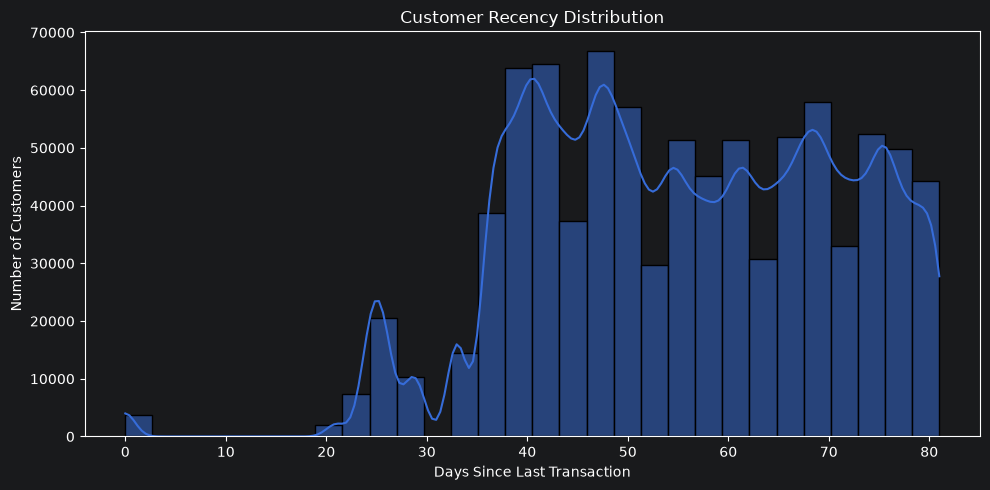

In [42]:
plt.figure(figsize=(10, 5))

sns.histplot(
    customer_master_clean["recency_days"],
    bins=30,
    kde=True
)

plt.title("Customer Recency Distribution")
plt.xlabel("Days Since Last Transaction")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

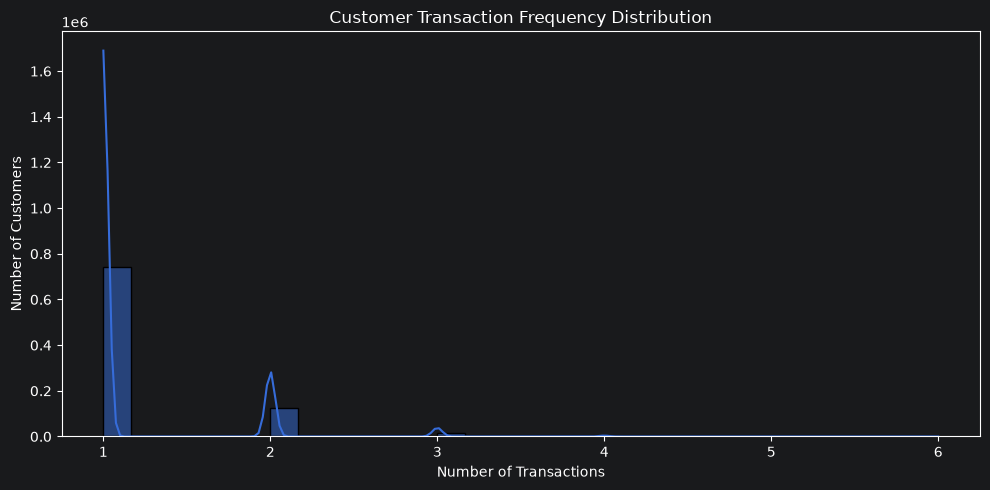

In [43]:
plt.figure(figsize=(10, 5))

sns.histplot(
    customer_master_clean["frequency"],
    bins=30,
    kde=True
)

plt.title("Customer Transaction Frequency Distribution")
plt.xlabel("Number of Transactions")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

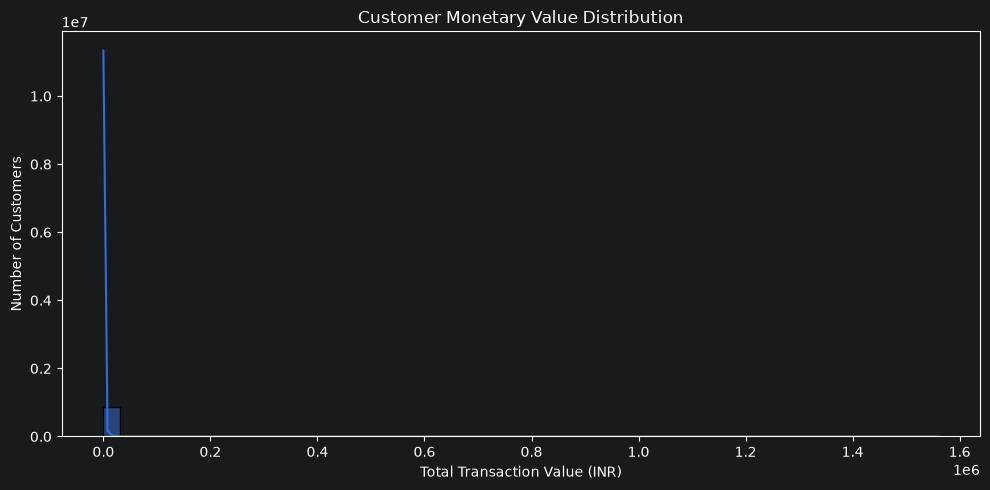

In [44]:
plt.figure(figsize=(10, 5))

sns.histplot(
    customer_master_clean["monetary_value_inr"],
    bins=50,
    kde=True
)

plt.title("Customer Monetary Value Distribution")
plt.xlabel("Total Transaction Value (INR)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [45]:
# Log transform RFM variables

customer_master_clean["recency_log"] = np.log1p(
    customer_master_clean["recency_days"]
)

customer_master_clean["frequency_log"] = np.log1p(
    customer_master_clean["frequency"]
)

customer_master_clean["monetary_log"] = np.log1p(
    customer_master_clean["monetary_value_inr"]
)

log_rfm_features = [
    "recency_log",
    "frequency_log",
    "monetary_log"
]

display(
    customer_master_clean[log_rfm_features].describe().T
)

,count,mean,std,min,25%,50%,75%,max
recency_log,884265.0,3.980429,0.382086,0.000000,3.784190,4.025352,4.234107,4.406719
frequency_log,884265.0,0.765572,0.170149,0.693147,0.693147,0.693147,0.693147,1.945910
monetary_log,884265.0,6.251212,1.612206,0.000000,5.303305,6.287487,7.313887,14.260219


In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    customer_master_clean[log_rfm_features]
)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=log_rfm_features,
    index=customer_master_clean.index
)

print("RFM scaling completed.")

display(rfm_scaled.head())

RFM scaling completed.


,recency_log,frequency_log,monetary_log
0,-1.890500,1.957345,1.418650
1,0.663929,-0.425655,0.658730
2,0.916822,1.957345,0.640264
3,-0.967090,-0.425655,-1.747435
4,0.507631,-0.425655,1.405641


In [47]:
# Prepare a representative sample for cluster selection

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_rfm = rfm_scaled[
    ["recency_log", "frequency_log", "monetary_log"]
]

# Reproducible sample
X_sample = X_rfm.sample(
    n=min(100_000, len(X_rfm)),
    random_state=42
)

print("Sample size:", f"{len(X_sample):,}")

Sample size: 100,000


In [48]:
# Elbow method

inertia_values = []
k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_sample)
    inertia_values.append(kmeans.inertia_)

print("Elbow analysis completed.")

for k, inertia in zip(k_values, inertia_values):
    print(f"K={k}: Inertia={inertia:,.2f}")

Elbow analysis completed.
K=2: Inertia=193,247.50
K=3: Inertia=143,104.90
K=4: Inertia=101,383.95
K=5: Inertia=80,107.21
K=6: Inertia=66,233.61
K=7: Inertia=59,223.18
K=8: Inertia=52,870.67


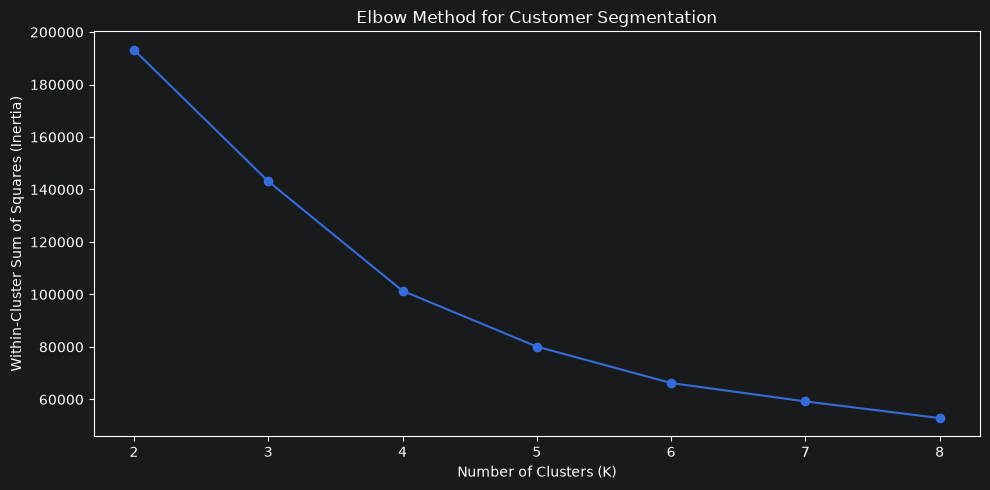

In [49]:
plt.figure(figsize=(10, 5))

plt.plot(
    list(k_values),
    inertia_values,
    marker="o"
)

plt.title("Elbow Method for Customer Segmentation")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.xticks(list(k_values))

plt.tight_layout()
plt.show()

In [50]:
# Silhouette score analysis

silhouette_values = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_sample)

    score = silhouette_score(
        X_sample,
        labels
    )

    silhouette_values.append(score)

    print(
        f"K={k}: Silhouette Score={score:.4f}"
    )

K=2: Silhouette Score=0.5304
K=3: Silhouette Score=0.3588
K=4: Silhouette Score=0.3741
K=5: Silhouette Score=0.3753
K=6: Silhouette Score=0.3719
K=7: Silhouette Score=0.3687
K=8: Silhouette Score=0.3667


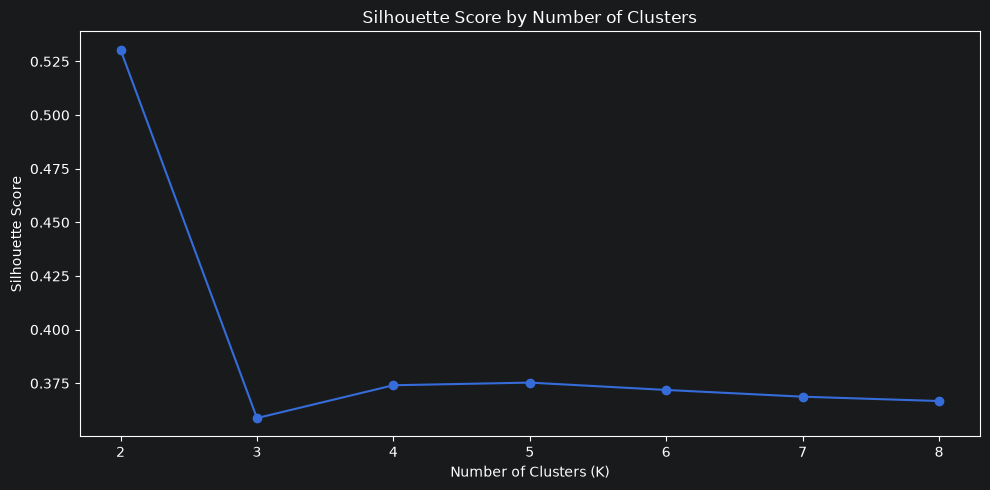

In [51]:
plt.figure(figsize=(10, 5))

plt.plot(
    list(k_values),
    silhouette_values,
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))

plt.tight_layout()
plt.show()

In [52]:
# Final K-Means customer segmentation model

final_k = 5

kmeans_final = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

customer_master_clean["cluster"] = kmeans_final.fit_predict(
    rfm_scaled
)

print("Final K-Means model trained successfully.")
print(f"Number of clusters: {final_k}")

Final K-Means model trained successfully.
Number of clusters: 5


In [53]:
# Customer count per cluster

cluster_counts = (
    customer_master_clean["cluster"]
    .value_counts()
    .sort_index()
)

cluster_summary = pd.DataFrame({
    "cluster": cluster_counts.index,
    "customer_count": cluster_counts.values,
    "percentage": (
        cluster_counts.values /
        len(customer_master_clean) * 100
    ).round(2)
})

display(cluster_summary)

,cluster,customer_count,percentage
0,0,255319,28.87
1,1,142391,16.10
2,2,203762,23.04
3,3,279139,31.57
4,4,3654,0.41


In [54]:
# Profile customer segments

cluster_profile = (
    customer_master_clean
    .groupby("cluster")
    .agg(
        customers=("customerid", "count"),
        avg_recency_days=("recency_days", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary_value_inr=("monetary_value_inr", "mean"),
        avg_transaction_inr=("average_transaction_inr", "mean"),
        avg_account_balance_inr=("average_account_balance_inr", "mean"),
        avg_age=("age", "mean")
    )
    .round(2)
)

display(cluster_profile)

,customers,avg_recency_days,avg_frequency,avg_monetary_value_inr,avg_transaction_inr,avg_account_balance_inr,avg_age
cluster,,,,,,,
0,255319,61.55,1.00,129.17,129.17,61637.92,25.96
1,142391,47.96,2.14,3369.95,1571.84,117290.57,25.80
2,203762,40.03,1.00,985.19,985.19,109208.99,26.24
3,279139,65.22,1.00,3323.61,3323.61,166915.33,25.38
4,3654,0.00,1.37,2592.31,1980.59,105593.28,26.19


In [55]:
# Median profile for each customer segment

cluster_median = (
    customer_master_clean
    .groupby("cluster")
    .agg(
        median_recency_days=("recency_days", "median"),
        median_frequency=("frequency", "median"),
        median_monetary_value_inr=("monetary_value_inr", "median"),
        median_account_balance_inr=(
            "average_account_balance_inr",
            "median"
        )
    )
    .round(2)
)

display(cluster_median)

,median_recency_days,median_frequency,median_monetary_value_inr,median_account_balance_inr
cluster,,,,
0,62.0,1.0,100.0,10234.36
1,46.0,2.0,1425.0,29296.92
2,41.0,1.0,500.0,18301.12
3,67.0,1.0,1250.0,26267.02
4,0.0,1.0,677.5,23340.21


In [56]:
# Gender distribution by cluster

gender_distribution = pd.crosstab(
    customer_master_clean["cluster"],
    customer_master_clean["gender"],
    normalize="index"
) * 100

gender_distribution = gender_distribution.round(2)

display(gender_distribution)

gender,F,M,T,Unknown
cluster,,,,
0,23.71,76.15,0.0,0.14
1,26.85,73.15,0.0,0.00
2,27.23,72.68,0.0,0.09
3,29.52,70.38,0.0,0.10
4,27.67,72.33,0.0,0.00


In [57]:
# Top locations within each cluster

for cluster in sorted(
    customer_master_clean["cluster"].unique()
):
    print(f"\nCluster {cluster}")
    print("=" * 50)

    top_locations = (
        customer_master_clean[
            customer_master_clean["cluster"] == cluster
        ]["location"]
        .value_counts()
        .head(10)
    )

    display(top_locations)



Cluster 0


location
MUMBAI       20555
BANGALORE    19054
NEW DELHI    17812
DELHI        17079
GURGAON      16969
NOIDA         7954
CHENNAI       6533
PUNE          6079
HYDERABAD     5786
THANE         5029
Name: count, dtype: int64


Cluster 1


location
MUMBAI       14028
NEW DELHI    11651
BANGALORE    10976
GURGAON       9781
DELHI         9728
NOIDA         4436
CHENNAI       4134
PUNE          3614
HYDERABAD     3033
THANE         2927
Name: count, dtype: int64


Cluster 2


location
MUMBAI       20954
BANGALORE    16459
NEW DELHI    16339
GURGAON      15027
DELHI        14122
NOIDA         6511
CHENNAI       6457
PUNE          5123
HYDERABAD     4535
THANE         4327
Name: count, dtype: int64


Cluster 3


location
MUMBAI       31325
NEW DELHI    25361
BANGALORE    21846
GURGAON      20339
DELHI        18710
NOIDA         8631
CHENNAI       8123
PUNE          6714
HYDERABAD     5943
KOLKATA       5934
Name: count, dtype: int64


Cluster 4


location
MUMBAI       356
BANGALORE    295
NEW DELHI    295
DELHI        248
GURGAON      232
CHENNAI      121
NOIDA        116
PUNE         101
HYDERABAD     85
THANE         83
Name: count, dtype: int64

In [58]:
# Customer count and percentage by cluster

cluster_summary = (
    customer_master_clean["cluster"]
    .value_counts()
    .sort_index()
    .to_frame("customer_count")
)

cluster_summary["percentage"] = (
    cluster_summary["customer_count"]
    / len(customer_master_clean)
    * 100
).round(2)

display(cluster_summary)

,customer_count,percentage
cluster,,
0,255319,28.87
1,142391,16.10
2,203762,23.04
3,279139,31.57
4,3654,0.41


In [59]:
# Detailed customer segment profile

cluster_profile = (
    customer_master_clean
    .groupby("cluster")
    .agg(
        customers=("customerid", "count"),
        avg_recency_days=("recency_days", "mean"),
        median_recency_days=("recency_days", "median"),
        avg_frequency=("frequency", "mean"),
        median_frequency=("frequency", "median"),
        avg_monetary_value_inr=("monetary_value_inr", "mean"),
        median_monetary_value_inr=("monetary_value_inr", "median"),
        avg_transaction_inr=("average_transaction_inr", "mean"),
        avg_account_balance_inr=("average_account_balance_inr", "mean"),
        median_account_balance_inr=(
            "average_account_balance_inr",
            "median"
        ),
        avg_age=("age", "mean")
    )
    .round(2)
)

display(cluster_profile)

,customers,avg_recency_days,median_recency_days,avg_frequency,median_frequency,avg_monetary_value_inr,median_monetary_value_inr,avg_transaction_inr,avg_account_balance_inr,median_account_balance_inr,avg_age
cluster,,,,,,,,,,,
0,255319,61.55,62.0,1.00,1.0,129.17,100.0,129.17,61637.92,10234.36,25.96
1,142391,47.96,46.0,2.14,2.0,3369.95,1425.0,1571.84,117290.57,29296.92,25.80
2,203762,40.03,41.0,1.00,1.0,985.19,500.0,985.19,109208.99,18301.12,26.24
3,279139,65.22,67.0,1.00,1.0,3323.61,1250.0,3323.61,166915.33,26267.02,25.38
4,3654,0.00,0.0,1.37,1.0,2592.31,677.5,1980.59,105593.28,23340.21,26.19


In [60]:
# Assign business-friendly segment names

segment_names = {
    0: "Low-Value Dormant Customers",
    1: "High-Value Active Customers",
    2: "Recent Moderate-Spend Customers",
    3: "High-Value At-Risk Customers",
    4: "Recently Active Customers"
}

customer_master_clean["segment"] = (
    customer_master_clean["cluster"]
    .map(segment_names)
)

display(
    customer_master_clean[
        [
            "customerid",
            "cluster",
            "segment",
            "recency_days",
            "frequency",
            "monetary_value_inr"
        ]
    ].head(20)
)

,customerid,cluster,segment,recency_days,frequency,monetary_value_inr
0,C1010011,1,High-Value Active Customers,25,2,5106.00
1,C1010012,3,High-Value At-Risk Customers,68,1,1499.00
2,C1010014,1,High-Value Active Customers,75,2,1455.00
3,C1010018,0,Low-Value Dormant Customers,36,1,30.00
4,C1010024,3,High-Value At-Risk Customers,64,1,5000.00
5,C1010028,2,Recent Moderate-Spend Customers,53,1,557.00
6,C1010031,1,High-Value Active Customers,78,2,1864.00
7,C1010035,1,High-Value Active Customers,55,2,750.00
8,C1010036,0,Low-Value Dormant Customers,56,1,208.00
9,C1010037,3,High-Value At-Risk Customers,73,1,19680.00


In [61]:
# Final customer segment summary

segment_summary = (
    customer_master_clean
    .groupby(["cluster", "segment"])
    .agg(
        customers=("customerid", "count"),
        avg_recency_days=("recency_days", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary_value_inr=("monetary_value_inr", "mean"),
        avg_account_balance_inr=(
            "average_account_balance_inr",
            "mean"
        )
    )
    .reset_index()
)

segment_summary["customer_percentage"] = (
    segment_summary["customers"]
    / len(customer_master_clean)
    * 100
).round(2)

segment_summary = segment_summary.round(2)

display(segment_summary)

,cluster,segment,customers,avg_recency_days,avg_frequency,avg_monetary_value_inr,avg_account_balance_inr,customer_percentage
0,0,Low-Value Dormant Customers,255319,61.55,1.00,129.17,61637.92,28.87
1,1,High-Value Active Customers,142391,47.96,2.14,3369.95,117290.57,16.10
2,2,Recent Moderate-Spend Customers,203762,40.03,1.00,985.19,109208.99,23.04
3,3,High-Value At-Risk Customers,279139,65.22,1.00,3323.61,166915.33,31.57
4,4,Recently Active Customers,3654,0.00,1.37,2592.31,105593.28,0.41


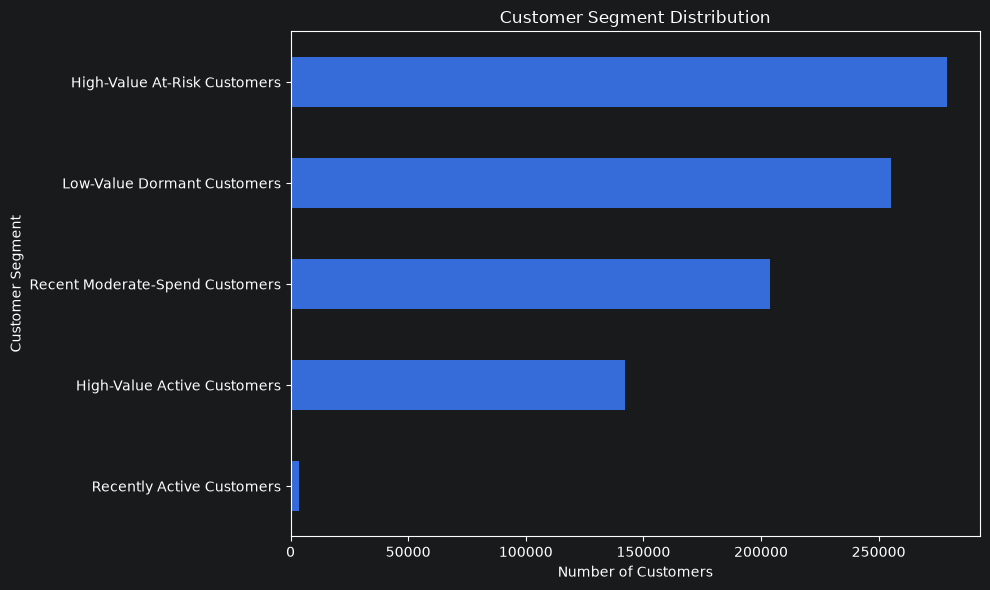

In [62]:
# Customer segment distribution

segment_plot = (
    customer_master_clean["segment"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

segment_plot.plot(
    kind="barh"
)

plt.title("Customer Segment Distribution")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

In [63]:
# Save customer segmentation results

customer_master_clean.to_csv(
    "../Data/processed/customer_segmentation.csv",
    index=False
)

segment_summary.to_csv(
    "../Data/processed/customer_segment_summary.csv",
    index=False
)

print("Customer segmentation datasets saved successfully.")

Customer segmentation datasets saved successfully.
